# Tarea 1: Modelos autorregresivos y LLMs
## MDS7203 Modelos Generativos Profundos
### Magíster en Ciencia de Datos - Universidad de Chile
#### Primavera, 2025

---

**Estudiante:** _[Nombre Completo]_

---

## Instrucciones generales

Esta tarea está compuesta por dos preguntas. En la primera pregunta se pide realizar fine tuning usando LoRA sobre un LLM base (LLaMA 3.2 1B) para generar salidas estructuradas tipo JSON a partir de un texto libre dado como entrada. En la segunda pregunta, se pide implementar manualmente el chat template de LLaMA 3.2 1B Instruct, y un sistema de uso de herramientas mediante prompting.

- El trabajo es individual y debe ser realizado en Google Colab.
- Se pueden usar libremente herramientas como ChatGPT, Gemini o Claude.
- La nota de la tarea corresponde al promedio simple de las notas de cada pregunta.
- Se debe entregar este notebook completamente ejecutado, y debe poder volver a ejecutarse sin ningún problema.
- Solo se pueden utilizar las indicadas en la siguiente celda.

In [ ]:
# Instalación de dependencias (no es necesario en Google Colab):
#!pip install -q torch transformers huggingface_hub accelerate matplotlib tqdm ipywidgets

import re
import csv
import gc
import json

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando {DEVICE}.')

Usando cuda.


En esta tarea se utilizarán modelos de la familia LLaMA, los cuales se pueden descargar a través de la API de Hugging Face. Para esto, es necesario aceptar los términos y condiciones de uso, y luego iniciar sesión en este Jupyter Notebook.

Por lo tanto, antes de comenzar la tarea es necesario:

1. [Crear una cuenta](https://huggingface.co/join) Hugging Face si no se tiene una.
2. Con la sesión iniciada, solicitar autorización de uso para los modelos [`Llama-3.2-1B`](https://huggingface.co/meta-llama/Llama-3.2-1B) y [`Llama-3.2-1B-Instruct`](https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct). Estos serán los modelos que se utilizarán a lo largo de la tarea.
3. [Crear un token](https://huggingface.co/settings/tokens) de Hugging Face con permiso de lectura. Este token se utilizará para iniciar sesión en Hugging Face desde este Jupyter Notebook.
4. Autenticarse utilizando la API de Hugging Face (siguiente celda). Es importante **borrar el token puesto en `HF_TOKEN` antes de entregar la tarea** ya que los tokens son personales y secretos.


In [ ]:
HF_TOKEN = ...
login(HF_TOKEN)

Para checkear que todo esté en orden, se descargará el modelo `Llama-3.2-1B` junto a su tokenizador:

In [4]:
model_name = 'meta-llama/Llama-3.2-1B'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,
    device_map='auto'
).to(DEVICE)

Notar que se asignó `tokenizer.pad_token = tokenizer.eos_token` debido a que el modelo LLaMA no define un token de padding nativo. Recordar que el token de padding es necesario para poder trabajar con batches de secuencias de largo distinto.

Por otro lado, se puede ver que la cantidad de parámetros de modelo es cercano a mil millones (1B):

In [5]:
total_params = sum(p.numel() for p in model.parameters())
print(f'Parametros totales: {total_params:,}.')

Parametros totales: 1,235,814,400.


Teniendo el modelo descargado se puede realizar generación autorregresiva utilizando el método `generate`. Este método abstrae todas las técnicas de sampling que se revisaron en clases.

In [6]:
input_text = '¿Cuál es la capital de Chile?'
inputs = tokenizer(input_text, return_tensors='pt').to(DEVICE)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_length=50,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2,
        pad_token_id=tokenizer.eos_token_id
    )

decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(f'INPUT:  {repr(input_text)}')
print(f'OUTPUT: {repr(decoded_output[len(input_text):].strip())}')

INPUT:  '¿Cuál es la capital de Chile?'
OUTPUT: '¿Qué es el Parque Nacional Ñuble? Escriben alrededor del 40% de las familias chilenas. Los más afectados son los que tienen menos recursos económ'


Se observa que el modelo no es capaz de responder la pregunta debido a que fue entrenado de forma autorregresiva (i.e., buscando generar el siguiente token) y no ha pasado por un post-entrenamiento para aprender a seguir instrucciones. Si bien se podría utilizar la variante _Instruct_, se hará fine tuning sobre este modelo base para adaptar su comportamiento.

## Pregunta 1: Fine tuning usando LoRA

El objetivo de esta pregunta es hacer fine tuning sobre el LLM recién descargado para que, dado un texto de entrada, pueda generar un texto estructurado (JSON) con información relevante extraída del texto.

### Parte 1.1: Dataset de entrenamiento

Para el fine tuning, se utilizará el dataset sintético `client_messages.json`, donde cada instancia de entrenamiento contiene las siguientes llaves:

- `input`: mensaje de un cliente a una aerolínea, solicitando la reserva de un vuelo.
- `output`: objeto JSON (escrito como texto plano) con información relevante extraída desde el documento. Más prcisamente, cada JSON contiene las llaves:
    - `nombre`: nombre del pasajero.
    - `origen`: ciudad de origen.
    - `destino`: ciudad de destino.
    - `fecha`: fecha de viaje (en formato AAAA-MM-DD).

Dado que el modelo no es capaz de distinguir entre tokens de entrada y tokens generados, es necesario usar separadores que le permitan al modelo poder identificar cuánto comenzar a generar la respuesta. En este caso, se utilizará `Usuario:` y `Asistente:` para definir una plantilla que separe `input` y `output`. De este modo, cada instancia de entrenamiento será una secuencia de tokens de la forma

```
Usuario:{input}\nAsistente:{output}
```

donde el modelo recibirá el prompt `Usuario:{input}\nAsistente:`, y tendrá que aprender a generar `{output}`. Para esto, implemente la clase `SimpleDataset` que cargue un archivo JSON con el formato descrito anteriormente. Más precisamente:
- Se debe poder instanciar el dataset para `train` o para `eval`, haciendo hold-out del JSON original.
- Se debe seguir la estructura estándar de Hugging Face. Es decir, cada instancia de entrenamiento es un diccionario compuesto por:
    - Una llave `input_ids` asociada a los tokens de la secuencia.
    - Una llave `labels` asociada a los tokens objetivo que se deben generar.
- Dado que solo es importante evaluar la generación condicional (i.e., `{output}`), el cálculo de la función de pérdida no debe considerar la generación del prompt `Usuario:{input}\nAsistente:`. Para esto, es usual marcar los tokens que se desean omitir en el cálculo de la entropía cruzada sustituyendo sus respectivos labels por el valor `-100`.

In [ ]:
class SimpleDataset(Dataset):

    def __init__(self, json_file, tokenizer, split='train', test_size=0.2):

        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)

        split_idx = int(len(data) * (1 - test_size))
        if split == 'train':
            self.data = data[:split_idx]
        else:
            self.data = data[split_idx:]

        self.tokenizer = tokenizer

        self.processed_data = []

        for item in self.data:
            ...

    def __len__(self):
        return len(self.processed_data)

    def __getitem__(self, idx):
        return self.processed_data[idx]

Los siguientes ejemplos permiten ver si la clase quedó bien implementada:

In [8]:
train_dataset = SimpleDataset('client_messages.json', tokenizer, split='train')
test_dataset = SimpleDataset('client_messages.json', tokenizer, split='test')

# Cantidad de muestras:
print(f'- Dataset de entrenamiento: {len(train_dataset):3} muestras.')
print(f'- Dataset de validación:    {len(test_dataset):3} muestras.')

# Estructura de una muestra:
sample = train_dataset[0]
print(f'\nLlaves de cada muestra: {list(sample.keys())}')
print(f'- Shape input_ids: {sample["input_ids"].shape}')
print(f'- Shape labels:    {sample["labels"].shape}')

# Ejemplo:
sample_text = tokenizer.decode(sample['input_ids'])
labels_text = tokenizer.decode(sample['labels'][sample['labels'] != -100])
print(f'\ninput_ids:                  {repr(sample_text)}')
print(f'labels (usadas en la loss): {repr(labels_text)}')

- Dataset de entrenamiento: 242 muestras.
- Dataset de validación:     61 muestras.

Llaves de cada muestra: ['input_ids', 'labels']
- Shape input_ids: torch.Size([244])
- Shape labels:    torch.Size([244])

input_ids:                  'Usuario:Quería reservar un vuelo de Santiago al sur para el próximo 15 de marzo, me gustaría saber si tiene disponible un vuelo desde el Aeroparque a Concepción para 4 personas. Mi familia está asistiendo a un evento en la ciudad y yo estoy preocupado por el clima, espero que no vaya a hacer mucho sol. ¿Qué tipo de asientos están disponibles? \n\nAdemás, ¿puedo pedir a cambio de una mejor ubicación más cerca del aeropuerto? Me gustaría evitar largas caminatas con maleta. \n\nTambién me gustaría saber el costo total de la reserva incluyendo impuestos y todos los cargos. Me gustaría hacer la reserva ahora mismo, ¿qué pasos necesito seguir para completar la reserva? \n\nUna más, ¿puedo pagar la reserva con tarjeta de crédito en línea o necesito hacerlo por

Teniendo el dataset de entrenamiento y el prompt template a utilizar, se implementará la función `inference`, la cual:
1. Aplica el prompt template `Usuario:{user_input}\nAsistente:`.
2. Genera tokens autoregresivamente.
3. Decodifica y elimina el prefijo del prompt.
4. En el texto restante, intenta detectar un bloque JSON buscando el primer par de llaves equilibrado. Si el texto es parseable con `json.loads`, lo retorna; en caso contrario, retorna `None`.

Esta función está completamente implementada, por lo que solo se pide entender su funcionamiento.

In [9]:
def inference(model, tokenizer, user_input, max_new_tokens=100):

    prompt = f'Usuario:{user_input}\nAsistente:'
    inputs = tokenizer(prompt, return_tensors='pt').to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            temperature=0.3,
            do_sample=True,
            top_p=0.8,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)[len(prompt):].strip()

    try:
        if '{' in response and '}' in response:
            start = response.find('{')
            end = response.find('}', start) + 1
            json_str = response[start:end]
            return json.loads(json_str)
    except:
        pass

    return None

Se utilizará la función `inference` para ver si es posible obtener un JSON a partir del modelo base descargado anteriormente. Para esto, se utlizará el dataset de validación `test_dataset`:

In [10]:
for i in range(5):
    sample = test_dataset[i]
    input_text = tokenizer.decode(sample['input_ids'])
    user_input = input_text.split('Usuario:')[1].split('\nAsistente:')[0]
    result = inference(model, tokenizer, user_input)
    print(f'\nMENSAJE CLIENTE: {repr(user_input)}')
    print(f'JSON EXTRAÍDO:   {repr(result)}')


MENSAJE CLIENTE: 'Hola, soy Carlos Gómez, soy abogado y voy a Santiago a una reunión de trabajo el 15 de marzo. Necesito reservar un vuelo para llevar a mi hermano menor a Temuco para su curso de universidad. Llega el 2025-03-20. Necesito información sobre disponibilidad y costos de vuelo de la ciudad de Concepción a Temuco. ¿Tienen alguna promoción o descuento para estudiantes o familias? También, ¿cuál es el mejor itinerario con el vuelo más temprano posible? ¿Cuánto tiempo puedo llegar al aeropuerto de Temuco? ¿Tienen asistencia en el aeropuerto para personas con discapacidad? ¿Cuál es la política de reembolso en caso de cancelación? ¿Cuánto cuesta el parking?'
JSON EXTRAÍDO:   None

MENSAJE CLIENTE: 'Hola, soy Carlos Ramírez, estoy llamando para reservar un vuelo de ida y vuelta desde Santiago a Valparaíso para el próximo 25 de marzo. Me gustaría saber si hay disponible un vuelo para esa fecha, y si puede contarme un poco más sobre las opciones de asientos y presupuesto. No he res

Como era de esperarse, es muy poco probable que este modelo _decida_ generar un JSON ya que no ha sido entrenado para eso. En consecuencia, no es factible utilizar este modelo tal como está en este momento para poder obtener el comportamiento deseado, por lo que se debe aplicar alguna técnica de fine tuning usando el dataset (de entrenamiento) construido.

### Parte 1.2: Implementación de LoRA

Dado que un LLM puede ser costoso de entrenar (aunque `Llama-3.2-1B` es el modelo más pequeño dentro de la familia LLaMA), muchas veces es recomendable utilizar métodos que permitan disminuir la carga de cómputo y memoria necesaria para el entrenamiento. En esta sección se pide implementar la ténica [LoRA](https://arxiv.org/abs/2106.09685) para el fine tuning del LLM. Para esto, comience implementando la siguiente
clase `LoRALayer`, la cual aplica esta técnica sobre una capa lineal (objeto tipo `nn.Linear`).

Recuerde que LoRA _envuelve_ una capa lineal $x\in\mathbb{R}^n\mapsto Wx+b\in\mathbb{R}^m$ (con $W\in\mathcal{M}_{mn}(\mathbb{R})$ y $b\in\R^m$ parámetros entrenables) en una nueva capa

\begin{align*}
x\in\mathbb{R}^n\mapsto &(W+\tau AB)x+b\in\mathbb{R}^m\\
&= (Wx+b)+\tau ABx,
\end{align*}

donde $\tau=\frac{\alpha}{r}>0$ es un hiperparámetro de la capa LoRA, y $A\in\mathcal{M}_{mr}(\mathbb{R})$, $B\in\mathcal{M}_{rn}(\mathbb{R})$ son los nuevos parámetros entrenables (los parámetros antiguos $W\in\mathcal{M}_{mn}(\mathbb{R})$ y $b\in\R^m$ no se entrenan y quedan fijados a sus valores originales). De esta forma, si $r\ll \min\{m,n\}$, entonces la cantidad de parámetros que se debe entrenar ($mr+rn$) es considerablemente menor a la cantidad de parámetros que se tenía que entrenar usando la capa lineal ($mn+m$).

Por otro lado, es usual comenzar el fine tuning con LoRA considerando al producto $AB\in\mathcal{M}_{mn}(\mathbb{R})$ como la matriz nula para que la modificación a la capa lineal original sea gradual. Para esto, es suficiente inicializar cualquiera de las dos matrices como la matriz nula.

In [ ]:
class LoRALayer(nn.Module):

    def __init__(self, original_layer, rank, alpha):
        ...

    def forward(self, x):
        ...

Con la clase anterior definida, es necesario sustituir las capas lineales de la red neuronal que se busca entrenar por módulos tipo `LoRALayer`. Además, dado que no todas las capas tienen la misma importancia para el fine tuning, es usual aplicar LoRA solo a un conjunto de capas donde se sabe que el efecto del adaptador LoRA es importante, y se consideran todos los otros parámetros como no entrenables.

Para esto, la siguiente función `apply_lora` realiza lo siguiente:

1. Congela los parámetros originales de la red neuronal `model` para que no se actualicen en la optimización.
2. Recorre cada uno de los módulos que constituyen `model`.
3. Detecta los módulos lineales cuyo nombre contiene alguno de los sufijos objetivo en `target_modules`.
4. Sustituye estas capas lineales por instancias `LoRALayer` que _envuelven_ la capa lineal original.

In [12]:
def apply_lora(model, target_modules, rank, alpha):

    for param in model.parameters():
        param.requires_grad = False

    for name, module in model.named_modules():
        if any(target in name for target in target_modules) and isinstance(module, nn.Linear):
            parent_name = '.'.join(name.split('.')[:-1])
            child_name = name.split('.')[-1]
            parent_module = model.get_submodule(parent_name)

            lora_layer = LoRALayer(module, rank=rank, alpha=alpha)
            setattr(parent_module, child_name, lora_layer)

Al hacer fine tuning sobre LLMs, es usual aplicar LoRA únicamente a las capas lineales que forman parte del mecanismo de atención (i.e., las 3 proyecciones lineales y la proyeccion posterior a la concatenación de cabezales). En el caso del LLM que estamos usando, estas capas se identifican por los sufijos `q_proj`, `k_proj`, `v_proj` y `o_proj`.

Defina valores para los hiperparámetros $r\in\N$ y $\alpha>0$ que se utilizarán para el fine tuning con LoRA.

In [ ]:
rank = ...
alpha = ...

target_modules = ['q_proj', 'v_proj', 'k_proj', 'o_proj']

apply_lora(model, target_modules=target_modules, rank=rank, alpha=alpha)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parametros totales:     {total_params:,}')
print(f'Parametros entrenables: {trainable_params:,}')
print(f'Porcentaje entrenable:  {trainable_params/total_params*100:.2f}%')

Parametros totales:     1,237,518,336
Parametros entrenables: 1,703,936
Porcentaje entrenable:  0.14%


### Parte 1.3: Entrenamiento y evaluación

Para el entrenamiento faltan 3 cosas:
1. Definir un dataloader a partir del dataset construido.
2. Definir un optimizador para los parámetros entrenables de `model`.
3. Implementar el loop de entrenamiento.

Para definir el dataloader, se utilizará una _collate function_, la cual es una función que se aplica justo antes de retornar el batch por parte del dataloader. En este caso, la collate function que se pide implementar debe hacer la tarea de padding para el largo máximo del batch, es decir:
1. Debe calcular la longitud de secuencia máxima del batch.
2. Debe rellenar todos los `input_ids` del batch con `pad_token_id`.
3. Debe rellenar todos los `labels` del batch con el valor `-100` para ignorar el token de padding en el cálculo de la función de pérdida.

Si bien el proceso de padding se podría hacer al definir el dataset, hacerlo en una collate function permite tener largos máximos variables, dependiendo de las secuencias que tenga el batch. De este modo, no queda restringido todo el dataset a un mismo largo máximo, si no que el largo máximo queda definido por las instancias de entrenamiento que constituyen cada batch.

In [ ]:
def collate_fn(batch):
    ...

Por último, para crear el dataloader, defina un `batch_size` adecuado para la memoria GPU disponible (recordar que con `watch -n 1 nvidia-smi` se puede ver el uso de GPU en tiempo real). Para esto, comience asignándole un valor bajo y luego auméntelo durante el entrenamiento hasta donde permita la memoria.

In [ ]:
batch_size = ...
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

A continuación se pide completar el loop de entrenamiento en la función `train_model`. Para esto:

- Use como optimizador a `AdamW` e incluya un parámetro de `weight_decay` para regularizar el entrenamiento.
- Incluya la técnica de gradient clipping para estabilizar el entrenamiento. Puede ser útil el método `clip_grad_norm_`.
- Omita la actualización de parámetros si la función de pérdida diverge. Puede ser útil la función `isnan` de PyTorch.

Note que el cálculo de la función de pérdida lo realiza automáticamente la librería `transformers`: si `outputs` es la salida de la red neuronal, `outputs.loss` es el valor de la función de pérdida.

In [ ]:
def train_model(model, train_dataloader, epochs, learning_rate, max_grad_norm, weight_decay):

    optimizer = ...

    model.train()
    loss_history = []

    for epoch in range(epochs):
        ...

    plt.figure(figsize=(10, 6))
    plt.plot(loss_history)
    plt.xlabel('Iteración')
    plt.ylabel('Entropía cruzada')
    plt.title('Evolución del entrenamiento')
    plt.grid(alpha=0.3)
    plt.show()

Para realizar el entrenamiento, defina valores para los hiperparámetros considerados:

Epoca 1/1: 100%|██████████| 121/121 [00:28<00:00,  4.24it/s]


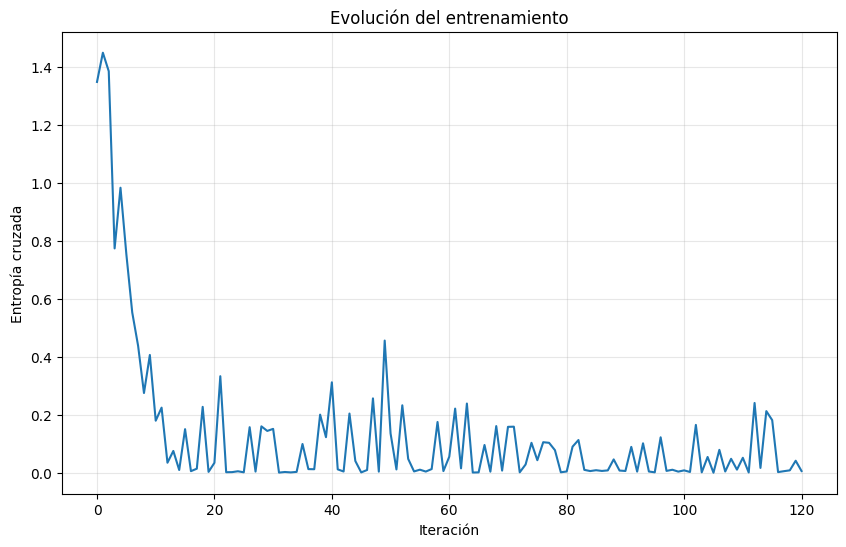

In [ ]:
epochs = ...
learning_rate = ...
max_grad_norm = ...
weight_decay = ...

train_model(model, train_dataloader, epochs, learning_rate, max_grad_norm, weight_decay)

El entrenamiento toma pocos minutos en Google Colab (usando una NVIDIA Tesla T4).

Para ver si el modelo fue capaz de aprender la estructura de salida deseada, se utilizará la misma función `inference` implementado en la Parte 1.1:

In [18]:
for i in range(5):
    sample = test_dataset[i]
    input_text = tokenizer.decode(sample['input_ids'])
    user_input = input_text.split('Usuario:')[1].split('\nAsistente:')[0]
    result = inference(model, tokenizer, user_input)
    print(f'\nMENSAJE CLIENTE: {repr(user_input)}')
    print(f'JSON EXTRAÍDO:   {repr(result)}')


MENSAJE CLIENTE: 'Hola, soy Carlos Gómez, soy abogado y voy a Santiago a una reunión de trabajo el 15 de marzo. Necesito reservar un vuelo para llevar a mi hermano menor a Temuco para su curso de universidad. Llega el 2025-03-20. Necesito información sobre disponibilidad y costos de vuelo de la ciudad de Concepción a Temuco. ¿Tienen alguna promoción o descuento para estudiantes o familias? También, ¿cuál es el mejor itinerario con el vuelo más temprano posible? ¿Cuánto tiempo puedo llegar al aeropuerto de Temuco? ¿Tienen asistencia en el aeropuerto para personas con discapacidad? ¿Cuál es la política de reembolso en caso de cancelación? ¿Cuánto cuesta el parking?'
JSON EXTRAÍDO:   {'nombre': 'Carlos Gómez', 'origen': 'Santiago', 'destino': 'Temuco', 'fecha': '2025-03-15'}

MENSAJE CLIENTE: 'Hola, soy Carlos Ramírez, estoy llamando para reservar un vuelo de ida y vuelta desde Santiago a Valparaíso para el próximo 25 de marzo. Me gustaría saber si hay disponible un vuelo para esa fecha,

Se observa que en todos los casos, el modelo genera un JSON parseable, el cual contiene la información correcta acerca de la entrada, lo que muestra que un par de iteraciones de entrenamiento pueden ser suficiente para modificar el comportamiento de un modelo. Es importante mencionar que en casos reales es necesario crear criterios de evaluación y métricas más sofisticadas para asegurar un buen funcionamiento.

Antes de continuar con la segunda pregunta, es necesario liberar la memoria GPU que quedó ocupada con el modelo `Llama-3.2-3B`:

In [19]:
del model

gc.collect()

torch.cuda.empty_cache()
torch.cuda.ipc_collect()

## Pregunta 2: Chat template y uso de herramientas

En esta segunda pregunta se pide usar un LLM entrenado para seguir instrucciones (`Llama-3.2-3B-Instruct`) para poder hacer uso de herramientas externas mediante prompting. Para esto, se comenzará implementando el chat template que utiliza este modelo, y luego se utilizará el template implementado para _conversar_ con el LLM y adaptarlo para el uso de herramientas usando una versión simplificada del enfoque [ReAct](https://arxiv.org/abs/2210.03629).

### Parte 2.1: Chat template de LLaMA

Para empezar, se descargará el tokenizador y el modelo instruct de manera similar a lo realizado con el modelo base:

In [20]:
model_instruct_name = 'meta-llama/Llama-3.2-3B-Instruct'

tokenizer_instruct = AutoTokenizer.from_pretrained(model_instruct_name)
model_instruct = AutoModelForCausalLM.from_pretrained(
    model_instruct_name,
    dtype=torch.float32,
    device_map='auto'
).to(DEVICE)

tokenizer_instruct.pad_token = tokenizer_instruct.eos_token

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Para poder utilizar correctamente este modelo, es necesario conocer que el modelo descargado fue post-entrenado utilizando el siguiente formato de template:

```
<|start_header_id|>system<|end_header_id|>
{SYSTEM_PROMPT}<|eot_id|>
<|start_header_id|>user<|end_header_id|>
{USER_PROMPT}<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>
```

Notar que el bloque del `assistant` no se cierra con `<|eot_id|>` ya que este prompt es usado como entrada al modelo para obtener la respuesta del `assistant` de forma autorregresiva.

Implemente la función `build_chat_template` que aplique este chat template a un `system_prompt` y `user_prompt` determinado:

In [ ]:
def build_chat_template(system_prompt, user_prompt):
    ...

Teniendo el chat template construido, se pide implementar la función `generate_response`, la cual debe realizar lo siguiente:

1. Recibir el prompt formateado (template aplicado a los `system_prompt` y `user_prompt` dados) y luego tokenizarlo.
2. Llamar a `model.generate` utilizando la secuencia de tokens obtenida en el paso anterior.
3. Decodificar los tokens nuevos, omitiendo los tokens dados como entrada.

In [ ]:
def generate_response(prompt, model=model_instruct, tokenizer=tokenizer_instruct):
    ...

Para probar el funcionamiento de las funciones implementadas, se evaluará la capacidad de respuesta del modelo con una pregunta simple:

In [23]:
system_prompt = 'Eres un asistente util que responde preguntas de forma concisa.'
user_prompt = '¿Cual es la capital de Chile?'

chat_template = build_chat_template(system_prompt, user_prompt)
print(f'PROMPT:')
print("=" * 80)
print(chat_template)
print("=" * 80)

response = generate_response(chat_template)
print(f'\nRESPUESTA GENERADA:')
print("=" * 80)
print(response)
print("=" * 80)

PROMPT:
<|start_header_id|>system<|end_header_id|>
Eres un asistente util que responde preguntas de forma concisa.
<|eot_id|>
<|start_header_id|>user<|end_header_id|>
¿Cual es la capital de Chile?
<|eot_id|>
<|start_header_id|>assistant<|end_header_id|>


RESPUESTA GENERADA:
Santiago.


Se observa que el template se está aplicando de forma correcta ya que el modelo puede responder sin problemas, siguiendo el template con el que fue entrenado.

### Parte 2.2: Uso de herramientas

En esta segunda parte se implementará un ejemplo de uso de herramientas mediante prompting, donde el LLM podrá consultar o agregar contactos a una agenda de contactos externa. Para esto, la siguiente clase `ContactManager` implementa la gestión de una agenda de contactos simple que permite buscar y agregar contactos. mediante los métodos `search_contact` y `add_contact` respectivamente. Los registros se almacenan en el archivo `contacts.csv`, el cual se puede interpretar como un tipo de memoria persistente para el LLM.

In [24]:
class ContactManager:

    def __init__(self, csv_file='contacts.csv'):
        self.csv_file = csv_file
        self.contacts = {}
        try:
            with open(self.csv_file, 'r', encoding='utf-8') as file:
                reader = csv.DictReader(file)
                for row in reader:
                    self.contacts[row['name']] = row['phone']
        except FileNotFoundError:
            pass

    def search_contact(self, name):
        '''Busca un contacto por nombre (búsqueda parcial).'''
        matches = []
        for contact_name, phone in self.contacts.items():
            if name.lower() in contact_name.lower():
                matches.append({'name': contact_name, 'phone': phone})
        return matches if matches else 'Contacto no encontrado.'

    def add_contact(self, name, phone):
        '''Agrega un nuevo contacto.'''
        self.contacts[name] = phone
        with open(self.csv_file, 'w', encoding='utf-8', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['name', 'phone'])
            for contact_name, contact_phone in self.contacts.items():
                writer.writerow([contact_name, contact_phone])
        return 'Contacto agregado exitosamente.'

In [25]:
contact_manager = ContactManager()

print("Buscar Juan:", contact_manager.search_contact("Juan"))

contact_manager.add_contact("Luis Morales", "+56 9 1234 5678")
print("Buscar Luis:", contact_manager.search_contact("Luis"))

Buscar Juan: [{'name': 'Juan Pérez', 'phone': '+56 9 8765 4321'}]
Buscar Luis: [{'name': 'Luis Riquelme', 'phone': '+569 1234 4321'}, {'name': 'Luis Morales', 'phone': '+56 9 1234 5678'}]


Ahora se implementará el framework ReAct (Reasoning + Acting) para permitir que el LLM pueda usar herramientas externas de manera estructurada. El paradigma ReAct funciona de la siguiente manera:

1. **Thought**: el modelo razona sobre la pregunta del usuario.
2. **Action**: si es necesario, ejecuta una herramienta específica.
3. **Observation**: recibe el resultado de la herramienta.
4. **Answer**: Proporciona la respuesta final al usuario.

Si bien este paradigma también suele repetir iterativamente este ciclo para lograr un objetivo más complejo, en esta implementación se considerará solo una fase de razonamiento y a lo más una llamada a una herramienta.

Ls herramientas disponibles en este caso son:
- `search_contact(name)`: busca un contacto por nombre.
- `add_contact(name, phone)`: agrega un nuevo contacto.

Ahora se pide implementar un system prompt robusto que le indique al modelo que debe _pensar_ siguiendo el enfoque ReAct, qué herramientas tiene disponibles y de qué forma tiene que usarlas. Para hacer más robusto el prompt, es usual incluir ejemplos de cómo debe _razonar_ el modelo.

In [ ]:
REACT_SYSTEM_PROMPT = ...

Teniendo el prompt que le indicará al LLM seguir el framework ReAct, ahora es necesario implementar la clase `ReActAgent`, la cual debe generar autorregresivamente la respuesta del modelo y detenerse si el modelo genera el separador `Observation:`. En este caso:
- El script debe identificar la herramienta y sus parámetros, las cuales están indicados luego de `Action:`.
- Se debe ejecutar la herramienta con los parámetros indicados.
- Se debe anexar lo que retorne la herramienta al texto generado (luego de `Observation:`).
- Se debe agregar el separador `Answer:` en la siguiente línea y continuar la generación.

Si no no se detecta el separador `Observation:`, no es necesario interrumpir la generación. En cualquier caso, al terminar la generación se debe identificar al texto después del separador `Answer:` para entregarlo como respuesta al usuario.

In [ ]:
class ReActAgent:
    
    def __init__(self, contact_manager):
        self.contact_manager = contact_manager
        self.model = model_instruct
        self.tokenizer = tokenizer_instruct
    
    def chat(self, user_question):
        '''
        Dada una pregunta del usuario, entregar la respuesta final junto al prompt completo procesado por el LLM.
        '''
        ...
        
        return {
            'full_prompt': final_prompt,
            'final_answer': final_answer
        }

Luego, basta inicializar el agente entregándole una agenda de contactos:

In [ ]:
agent = ReActAgent(contact_manager)

Para testear la implementación y la robustez del system prompt, se utilizará la siguiente función auxiliar, la cual recibe una pregunta del usuario y muestra el prompt completo que procesó junto a la respuesta obtenida:

In [ ]:
def test_agent(user_question, agent=agent):
    print("="*80)
    print(user_question)
    print("="*80)

    response = agent.chat(user_question)

    print("PROMPT COMPLETO PROCESADO POR EL LLM:")
    print("-" * 50)
    print(response['full_prompt'])
    print("-" * 50)
    print()

    print("RESPUESTA FINAL AL USUARIO:")
    print(f"'{response['final_answer']}'")
    print()
    print("="*80)

Se probará su funcionamiento con algunas preguntas simples:

In [30]:
test_agent("¿Cuál es el teléfono de María?")

¿Cuál es el teléfono de María?
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu respuesta final al usua

In [31]:
test_agent("¿Tienes el teléfono de Roberto?")

¿Tienes el teléfono de Roberto?
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu respuesta final al usu

In [32]:
test_agent("Agrega a Carlos Mendoza con teléfono +56 9 7777 8888")

Agrega a Carlos Mendoza con teléfono +56 9 7777 8888
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu r

In [33]:
test_agent("¿Cuál es la capital de Argentina?")

¿Cuál es la capital de Argentina?
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu respuesta final al u

In [34]:
test_agent("¿Tengo algún contacto de apellido Silva?")

¿Tengo algún contacto de apellido Silva?
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu respuesta fin

In [35]:
test_agent("¿Tienes el teléfono de Xóchitl?")

¿Tienes el teléfono de Xóchitl?
PROMPT COMPLETO PROCESADO POR EL LLM:
--------------------------------------------------
<|start_header_id|>system<|end_header_id|>
Eres un asistente inteligente que puede gestionar una agenda de contactos. Puedes responder preguntas generales y usar herramientas de la agenda cuando sea necesario.

Herramientas disponibles:
- search_contact(name): busca un contacto en la agenda por nombres. Entrega un diccionario con todos los contactos que coincidan con la búsqueda. Debes considerar todos los contactos encontrados en tu respuesta.
- add_contact(name, phone): agrega un nuevo contacto a la agenda. Entrega un mensaje de confirmación.

Formato de respuesta:
- Si necesitas usar una herramienta, sigue exactamente este formato:
  Thought: [tu razonamiento para responder la pregunta. Aquí es donde puedes si necesitas usar una herramienta]
  Action: [nombre_herramienta(argumentos)]
  Observation: [resultado de la herramienta]
  Answer: [tu respuesta final al usu